# OPX Lorentzian spectroscopy: experiment vs simulation

This notebook loads a Lorentzian or echo-Lorentzian OPX spectroscopy dataset, reconstructs the pulse parameters, runs the repository's QuTiP simulation at the same amplitudes and detunings, and compares 1D experimental and simulated spectra.

The comparison uses one shared readout offset/contrast and one shared frequency-zero offset. Those are measurement-calibration quantities, not changes to the pulse physics. Agreement supports consistency of the data with the model; it does not by itself prove that every experimental assumption is correct.

## 1. Imports and user settings

The notebook reads native OPX1000 runs from the sibling folder `data_opx1000/`. A run contains `parameters.json`, `results.npz`, `sweep.npz`, and its saved `profile/`. Set `DATA_RUN` below to select an exact run; otherwise a valid echo-Lorentzian run is chosen automatically.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, fields
from pathlib import Path
import json
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qutip import basis, destroy, mesolve, num
from scipy.stats import pearsonr

# Find the repository root whether Jupyter starts in the root or notebooks/.
PROJECT_ROOT = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "pyproject.toml").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from echospec.simulation.pulses import (
    PulseArgs, PulseType, choose_pulse,
)
from echospec.utils.parameters import Parameters
from echospec.utils.units import Units as u

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# The folder is a sibling of this repository in the current workspace.
DATA_DIR = PROJECT_ROOT.parent / "data_opx1000"
# Set to a run folder relative to DATA_DIR (or an absolute path) to override auto-selection.
DATA_RUN: Path | None = Path(
    "calibrations/2026-06-28/echo_lorentzian/13-26-28-471871"
)

# Select experimental Rabi-amplitude line cuts (nearest available values are used).
TARGET_AMPLITUDES_MHZ = (5.0, 10.0, 15.0)

# Simulation resolution. Increase these after a quick first run if desired.
SIM_DETUNING_POINTS = 121
SIM_TIME_POINTS = 400

# Coherence parameters are not present in the historical OPX JSON schema.
# A sidecar params.json or a top-level parameters/metadata object takes priority.
PARAMETER_FALLBACKS = {
    "T1": 30 * u.us,
    "T_dephasing": 20 * u.us,
    "anharmonicity": 400 * u.pi2 * u.MHz,
}

FIT_SHARED_FREQUENCY_OFFSET = True
MAX_OFFSET_FRACTION_OF_SPAN = 0.15


## 2. Load the OPX data and reconstruct its parameters

In [2]:
@dataclass(frozen=True)
class OpxDataset:
    path: Path
    detuning_hz: np.ndarray
    amplitudes_mhz: np.ndarray
    states: np.ndarray
    pulse_type: PulseType
    echo: bool
    pulse_length_s: float
    cutoff: float
    recorded_cutoff: float
    parameters: dict
    qubit: str
    pulse_shape: str
    output_amplitudes: np.ndarray
    num_shots: int

def choose_data_run() -> Path:
    if DATA_RUN is not None:
        path = Path(DATA_RUN)
        return path if path.is_absolute() else DATA_DIR / path
    if not DATA_DIR.exists():
        raise FileNotFoundError(f"OPX1000 data folder does not exist: {DATA_DIR}")

    candidates = []
    for parameter_file in DATA_DIR.rglob("echo_lorentzian/*/parameters.json"):
        run = parameter_file.parent
        if not (run / "results.npz").exists() or not (run / "sweep.npz").exists():
            continue
        try:
            settings = json.loads(parameter_file.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        shape = str(settings.get("pulse_shape", "")).lower()
        if "lorentzian" not in shape:
            continue
        try:
            with np.load(run / "sweep.npz", allow_pickle=False) as sweep_file:
                amp_count = int(np.asarray(sweep_file["amp_prefactor"]).size)
                detuning_count = int(np.asarray(sweep_file["detuning"]).size)
                qubit = str(np.asarray(sweep_file["qubit"])[0])
        except (OSError, KeyError, ValueError):
            continue
        recorded_cutoff = settings.get("cutoff", settings.get("root_lorentzian_cutoff", 1.0))
        recorded_cutoff = 1.0 if recorded_cutoff is None else float(recorded_cutoff)
        length_ns = float(settings.get("lorentzian_length_in_ns", 0.0))
        # Prefer high-shot echo root-Lorentzian runs with compact detuning grids.
        # DATA_RUN remains the explicit override for any other run.
        score = (
            20 <= detuning_count <= 250,
            bool(settings.get("echo", False)),
            shape == "root_lorentzian",
            amp_count >= 20,
            int(settings.get("num_shots", 0)),
            -detuning_count,
            recorded_cutoff < 0.1,
            qubit == "q1",
            -abs(length_ns - 20_000.0),
            str(run),
        )
        candidates.append((score, run))
    if not candidates:
        raise FileNotFoundError(f"No native Lorentzian runs found under {DATA_DIR}")
    return max(candidates, key=lambda item: item[0])[1]

def load_opx_run(run: Path) -> OpxDataset:
    settings = json.loads((run / "parameters.json").read_text())
    with np.load(run / "sweep.npz", allow_pickle=False) as sweep_file:
        detuning_hz = np.asarray(sweep_file["detuning"], dtype=float)
        amp_prefactor = np.asarray(sweep_file["amp_prefactor"], dtype=float)
        qubits = np.asarray(sweep_file["qubit"]).astype(str)
    qubit = str(qubits[0])
    with np.load(run / "results.npz", allow_pickle=False) as result_file:
        states = np.asarray(result_file["state"], dtype=float)
    if states.ndim == 3:
        states = states[0]
    if states.shape == (detuning_hz.size, amp_prefactor.size):
        states = states.T
    if states.shape != (amp_prefactor.size, detuning_hz.size):
        raise ValueError(
            f"state has shape {states.shape}; expected "
            f"({amp_prefactor.size}, {detuning_hz.size}) after selecting {qubit}."
        )

    pulse_profile = json.loads((run / "profile" / "pulses.json").read_text())
    qubit_profile = json.loads((run / "profile" / "qubits.json").read_text())
    x180 = pulse_profile["pulses"][qubit]["x180_const"]
    transmon = qubit_profile["qubits"][qubit]["transmon"]
    frequencies = qubit_profile["qubits"][qubit]["frequencies_hz"]

    peak_output_amplitude = float(settings["lorentzian_peak_amplitude"])
    output_amplitudes = amp_prefactor * peak_output_amplitude
    # Calibrate OPX output amplitude to Rabi frequency using the saved square-pulse pi calibration.
    x180_length_s = float(x180["length_ns"]) * u.ns
    rabi_per_output_amplitude_hz = 1.0 / (2.0 * x180_length_s * float(x180["amplitude"]))
    amplitudes_mhz = output_amplitudes * rabi_per_output_amplitude_hz / u.MHz

    T1_ns = transmon.get("t1_ns")
    T2_ns = transmon.get("t2_ramsey_ns")
    T1 = float(T1_ns) * u.ns if T1_ns else PARAMETER_FALLBACKS["T1"]
    if T2_ns:
        T2 = float(T2_ns) * u.ns
        inverse_Tphi = 1.0 / T2 - 1.0 / (2.0 * T1)
        T_dephasing = 1.0 / inverse_Tphi if inverse_Tphi > 0 else PARAMETER_FALLBACKS["T_dephasing"]
    else:
        T_dephasing = PARAMETER_FALLBACKS["T_dephasing"]
    pulse_shape = str(settings["pulse_shape"]).lower()
    recorded_cutoff = settings.get("cutoff", settings.get("root_lorentzian_cutoff"))
    if pulse_shape == "root_lorentzian":
        model_cutoff = float(recorded_cutoff)
    else:
        # The OPX standard Lorentzian uses tau directly; convert its edge ratio
        # to the equivalent Parameters cutoff used by echospec.
        template_ns = float(settings.get("waveform_template_length_in_ns") or settings["lorentzian_length_in_ns"])
        tau_ns = float(settings["lorentzian_tau_in_ns"])
        model_cutoff = 1.0 / (1.0 + (template_ns / (2.0 * tau_ns)) ** 2)
    anharmonicity_hz = transmon.get("anharmonicity_hz")
    qubit_frequency_hz = frequencies.get("qubit_f01")
    parameters = {
        "T1": T1,
        "T_dephasing": T_dephasing,
        "anharmonicity": float(anharmonicity_hz) * u.pi2 if anharmonicity_hz else PARAMETER_FALLBACKS["anharmonicity"],
        "qubit_frequency": float(qubit_frequency_hz) * u.pi2 if qubit_frequency_hz else Parameters().qubit_frequency,
        "order": 0.5 if pulse_shape == "root_lorentzian" else 1.0,
        "zeroed_pulse": False,
    }
    return OpxDataset(
        path=run,
        detuning_hz=detuning_hz,
        amplitudes_mhz=amplitudes_mhz,
        states=states,
        pulse_type=PulseType.LORENTZIAN,
        echo=bool(settings["echo"]),
        pulse_length_s=float(settings["lorentzian_length_in_ns"]) * u.ns,
        cutoff=model_cutoff,
        recorded_cutoff=float(recorded_cutoff) if recorded_cutoff is not None else np.nan,
        parameters=parameters,
        qubit=qubit,
        pulse_shape=pulse_shape,
        output_amplitudes=output_amplitudes,
        num_shots=int(settings.get("num_shots", 0)),
    )

dataset = load_opx_run(choose_data_run())
line_indices = np.unique([
    int(np.argmin(np.abs(dataset.amplitudes_mhz - target)))
    for target in TARGET_AMPLITUDES_MHZ
])
selected_amplitudes_mhz = dataset.amplitudes_mhz[line_indices]
experimental_raw = dataset.states[line_indices]

summary = pd.Series({
    "run": str(dataset.path.relative_to(DATA_DIR)),
    "qubit": dataset.qubit,
    "pulse": dataset.pulse_shape,
    "echo": dataset.echo,
    "pulse length (us)": dataset.pulse_length_s / u.us,
    "recorded cutoff": dataset.recorded_cutoff,
    "simulated edge/peak ratio": dataset.cutoff,
    "shots per point": dataset.num_shots,
    "detuning points": dataset.detuning_hz.size,
    "amplitude points": dataset.amplitudes_mhz.size,
    "selected amplitudes (MHz)": np.round(selected_amplitudes_mhz, 4).tolist(),
})
display(summary.to_frame("value"))


,value
run,calibrations/2026-06-28/echo_lorentzian/13-26-...
qubit,q1
pulse,lorentzian
echo,True
pulse length (us),20.0
recorded cutoff,0.02
simulated edge/peak ratio,0.000007
shots per point,200
detuning points,102
amplitude points,50


## 3. Simulate the selected 1D spectra with the same pulse parameters

The OPX sweep stores a dimensionless amplitude prefactor. This notebook converts it to $\Omega_0/2\pi$ using the saved `x180_const` pi-pulse amplitude and duration in the run profile. Detuning is stored in Hz. The solver receives both as angular frequencies in rad/s.

In [3]:
parameter_names = {field.name for field in fields(Parameters)}
physics_parameters = {
    key: value for key, value in dataset.parameters.items()
    if key in parameter_names and key not in {"pulse_type", "eco_pulse", "pulse_length", "cutoff", "rabi_frequency", "detuning"}
}
for key, fallback in PARAMETER_FALLBACKS.items():
    physics_parameters.setdefault(key, fallback)

simulation_detuning_hz = np.linspace(
    dataset.detuning_hz.min(),
    dataset.detuning_hz.max(),
    SIM_DETUNING_POINTS,
)

simulation_time_s = np.linspace(
    -dataset.pulse_length_s / 2,
    dataset.pulse_length_s / 2,
    SIM_TIME_POINTS,
)
pulse_args = PulseArgs(
    pulse_length=dataset.pulse_length_s,
    cutoff=dataset.cutoff,
    order=float(dataset.parameters["order"]),
    zeroed_pulse=bool(dataset.parameters.get("zeroed_pulse", False)),
)
pulse_function = choose_pulse(dataset.pulse_type, dataset.echo)
pulse_envelope = (
    np.ones_like(simulation_time_s)
    if pulse_function is None
    else pulse_function(simulation_time_s, pulse_args)
)
annihilation = destroy(2)
number = num(2)
drive_operator = 0.5 * (annihilation + annihilation.dag())
collapse_operators = [
    np.sqrt(1.0 / physics_parameters["T1"]) * annihilation,
    np.sqrt(2.0 / physics_parameters["T_dephasing"]) * number,
]

def simulate_linecut(amplitude_mhz: float) -> np.ndarray:
    # This is the same two-level Hamiltonian convention as the OPX1000
    # project's reference echo-Lorentzian QuTiP simulator.
    drive_rad_s = amplitude_mhz * u.pi2 * u.MHz * pulse_envelope
    populations = []
    for detuning_hz in simulation_detuning_hz:
        hamiltonian = [
            detuning_hz * u.pi2 * number,
            [drive_operator, drive_rad_s],
        ]
        result = mesolve(
            hamiltonian,
            basis(2, 0),
            simulation_time_s,
            c_ops=collapse_operators,
            e_ops=[number],
        )
        populations.append(float(np.real(result.expect[0][-1])))
    return np.asarray(populations)

simulated_grid = np.stack([simulate_linecut(amp) for amp in selected_amplitudes_mhz])
print(f"Simulated {simulated_grid.shape[0]} line cuts x {simulated_grid.shape[1]} detunings.")


Simulated 3 line cuts x 121 detunings.


## 4. Fit measurement-only calibration and compute agreement metrics

A single affine readout calibration is fit across all selected traces: `measured state = offset + contrast * simulated population`. Optionally, one shared detuning-zero offset is scanned. Pulse shape, pulse duration, cutoff, coherence values, amplitudes, and relative detuning points are not fit.

In [4]:
def interpolate_simulation(shared_offset_hz: float) -> np.ndarray:
    return np.stack([
        np.interp(
            dataset.detuning_hz - shared_offset_hz,
            simulation_detuning_hz,
            line,
            left=np.nan,
            right=np.nan,
        )
        for line in simulated_grid
    ])

def fit_readout(simulated: np.ndarray) -> tuple[float, float, float]:
    mask = np.isfinite(experimental_raw) & np.isfinite(simulated)
    design = np.column_stack([np.ones(mask.sum()), simulated[mask]])
    offset, contrast = np.linalg.lstsq(design, experimental_raw[mask], rcond=None)[0]
    residual = experimental_raw[mask] - (offset + contrast * simulated[mask])
    return float(offset), float(contrast), float(np.sqrt(np.mean(residual**2)))

span_hz = float(np.ptp(dataset.detuning_hz))
if FIT_SHARED_FREQUENCY_OFFSET:
    offset_candidates = np.linspace(
        -MAX_OFFSET_FRACTION_OF_SPAN * span_hz,
        MAX_OFFSET_FRACTION_OF_SPAN * span_hz,
        121,
    )
else:
    offset_candidates = np.array([0.0])

fits = []
for frequency_offset_hz in offset_candidates:
    simulated = interpolate_simulation(float(frequency_offset_hz))
    readout_offset, readout_contrast, raw_rmse = fit_readout(simulated)
    fits.append((raw_rmse, frequency_offset_hz, readout_offset, readout_contrast))
raw_rmse, frequency_offset_hz, readout_offset, readout_contrast = min(fits)
simulated_at_data = interpolate_simulation(float(frequency_offset_hz))
experimental_calibrated = (experimental_raw - readout_offset) / readout_contrast
residuals = experimental_calibrated - simulated_at_data

metric_rows = []
for amp, exp_line, sim_line, residual_line in zip(
    selected_amplitudes_mhz, experimental_calibrated, simulated_at_data, residuals
):
    mask = np.isfinite(exp_line) & np.isfinite(sim_line)
    rmse = float(np.sqrt(np.mean(residual_line[mask] ** 2)))
    mae = float(np.mean(np.abs(residual_line[mask])))
    ss_res = float(np.sum(residual_line[mask] ** 2))
    ss_tot = float(np.sum((exp_line[mask] - np.mean(exp_line[mask])) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    correlation = pearsonr(exp_line[mask], sim_line[mask]).statistic
    metric_rows.append({
        "amplitude_MHz": amp,
        "RMSE_population": rmse,
        "MAE_population": mae,
        "R_squared": r_squared,
        "Pearson_r": correlation,
    })
metrics = pd.DataFrame(metric_rows).set_index("amplitude_MHz")

calibration = pd.Series({
    "shared frequency offset (kHz)": frequency_offset_hz / u.kHz,
    "readout offset": readout_offset,
    "readout contrast": readout_contrast,
    "raw-state RMSE after global calibration": raw_rmse,
})
display(calibration.to_frame("value"))
display(metrics.round(4))


,value
shared frequency offset (kHz),-505.000000
readout offset,0.310553
readout contrast,0.606890
raw-state RMSE after global calibration,0.069858


,RMSE_population,MAE_population,R_squared,Pearson_r
amplitude_MHz,,,,
4.806143,0.0756,0.0640,-0.0678,0.5698
9.612286,0.1029,0.0795,0.5562,0.7602
14.418429,0.1531,0.1004,0.4838,0.7440


## 5. Diagnostic 1D plots

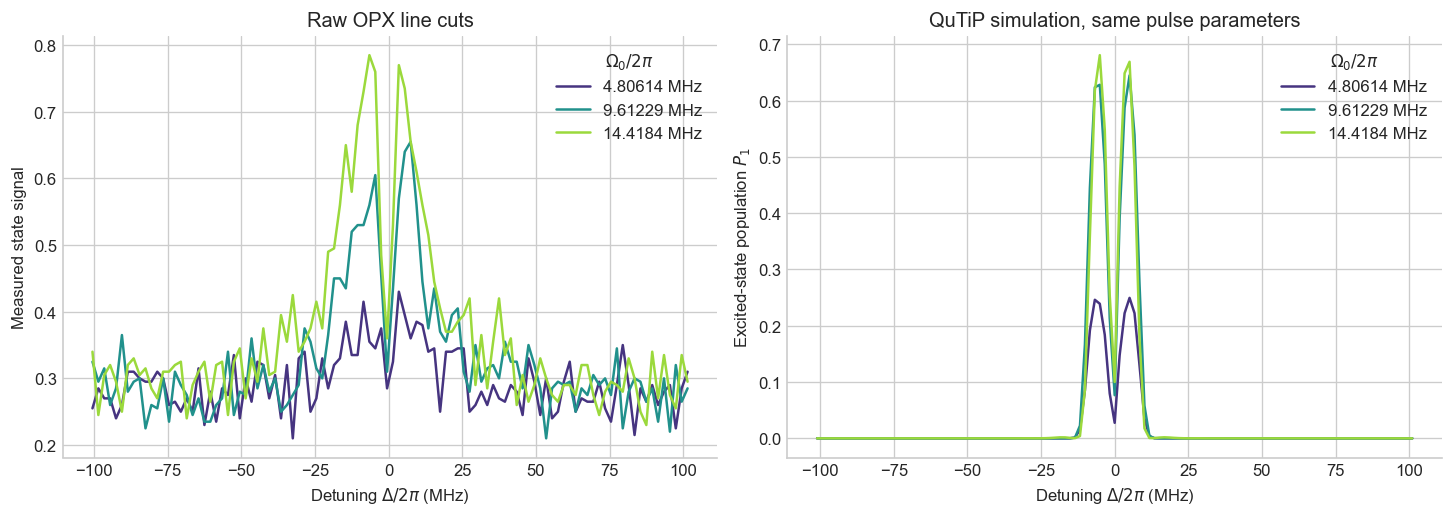

In [5]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_amplitudes_mhz)))
detuning_mhz = dataset.detuning_hz / u.MHz
simulation_detuning_mhz = (simulation_detuning_hz + frequency_offset_hz) / u.MHz

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for color, amp, exp_line, sim_line in zip(
    colors, selected_amplitudes_mhz, experimental_raw, simulated_grid
):
    axes[0].plot(detuning_mhz, exp_line, color=color, label=f"{amp:g} MHz")
    axes[1].plot(simulation_detuning_mhz, sim_line, color=color, label=f"{amp:g} MHz")
axes[0].set(title="Raw OPX line cuts", xlabel=r"Detuning $\Delta/2\pi$ (MHz)", ylabel="Measured state signal")
axes[1].set(title="QuTiP simulation, same pulse parameters", xlabel=r"Detuning $\Delta/2\pi$ (MHz)", ylabel=r"Excited-state population $P_1$")
for ax in axes:
    ax.legend(title=r"$\Omega_0/2\pi$")
plt.show()


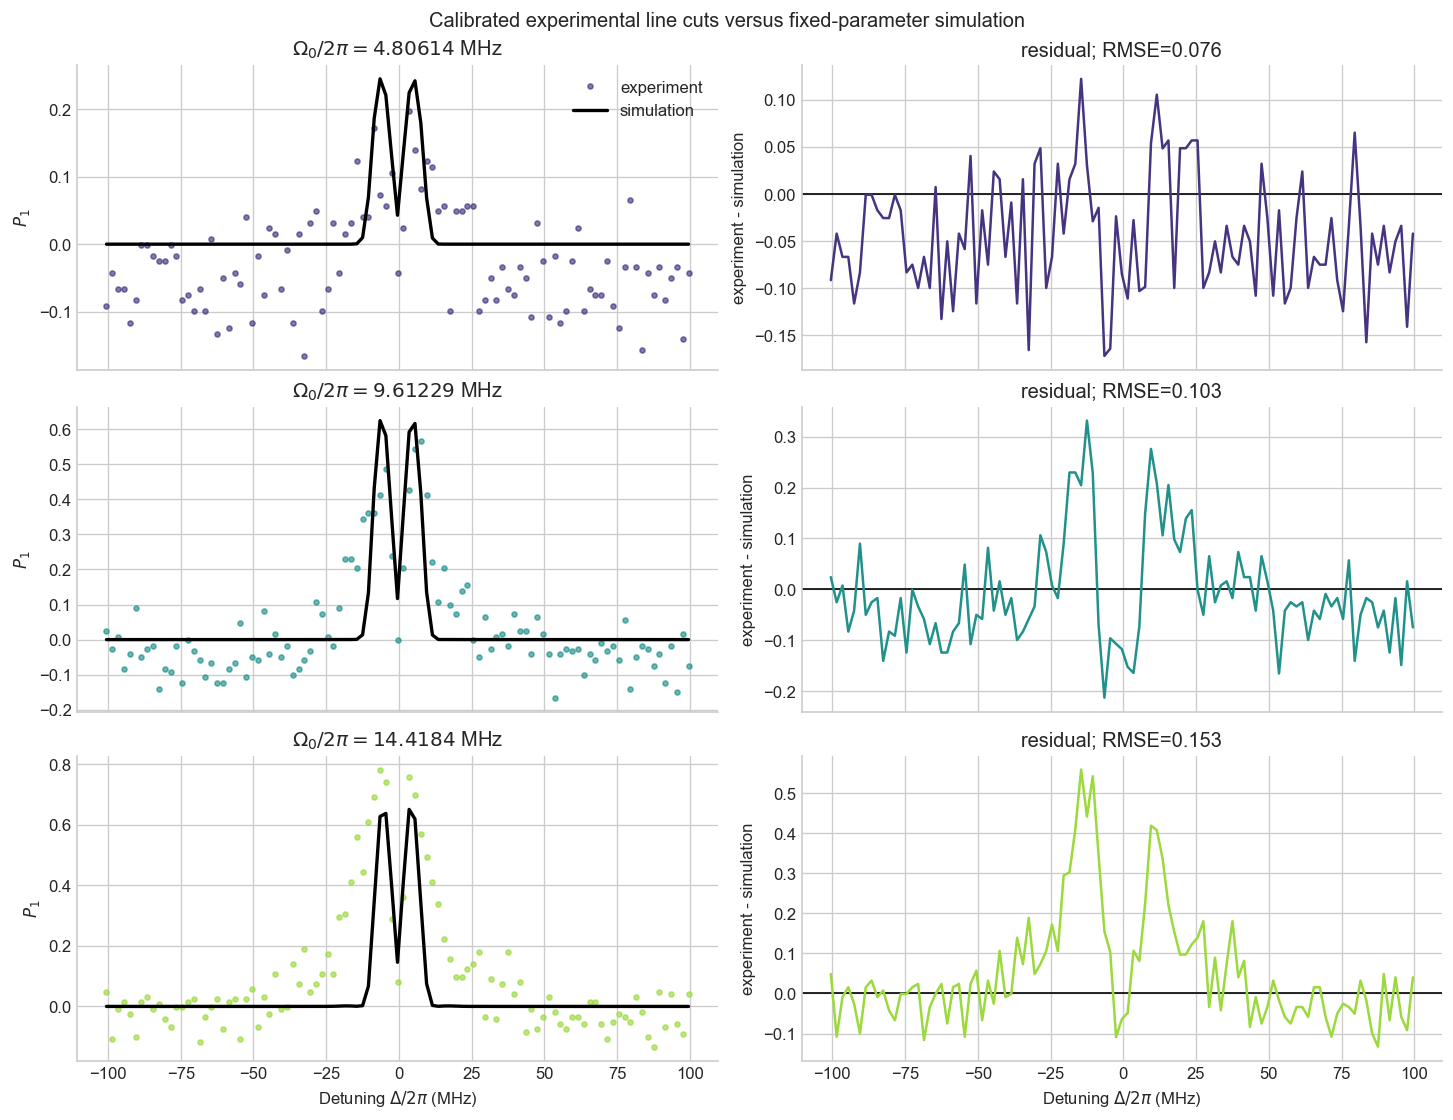

In [6]:
fig, axes = plt.subplots(
    len(selected_amplitudes_mhz), 2,
    figsize=(12, 3.0 * len(selected_amplitudes_mhz)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_2d(axes)
for row, (color, amp, exp_line, sim_line, residual_line) in enumerate(zip(
    colors, selected_amplitudes_mhz, experimental_calibrated, simulated_at_data, residuals
)):
    mask = np.isfinite(sim_line)
    axes[row, 0].plot(detuning_mhz[mask], exp_line[mask], "o", ms=3, color=color, alpha=0.65, label="experiment")
    axes[row, 0].plot(detuning_mhz[mask], sim_line[mask], "-", lw=2, color="black", label="simulation")
    axes[row, 0].set_ylabel(r"$P_1$")
    axes[row, 0].set_title(rf"$\Omega_0/2\pi = {amp:g}$ MHz")
    axes[row, 1].axhline(0, color="black", lw=1)
    axes[row, 1].plot(detuning_mhz[mask], residual_line[mask], color=color)
    axes[row, 1].set_ylabel("experiment - simulation")
    axes[row, 1].set_title(f"residual; RMSE={metrics.loc[amp, 'RMSE_population']:.3f}")
axes[0, 0].legend()
axes[-1, 0].set_xlabel(r"Detuning $\Delta/2\pi$ (MHz)")
axes[-1, 1].set_xlabel(r"Detuning $\Delta/2\pi$ (MHz)")
fig.suptitle("Calibrated experimental line cuts versus fixed-parameter simulation", y=1.02)
plt.show()


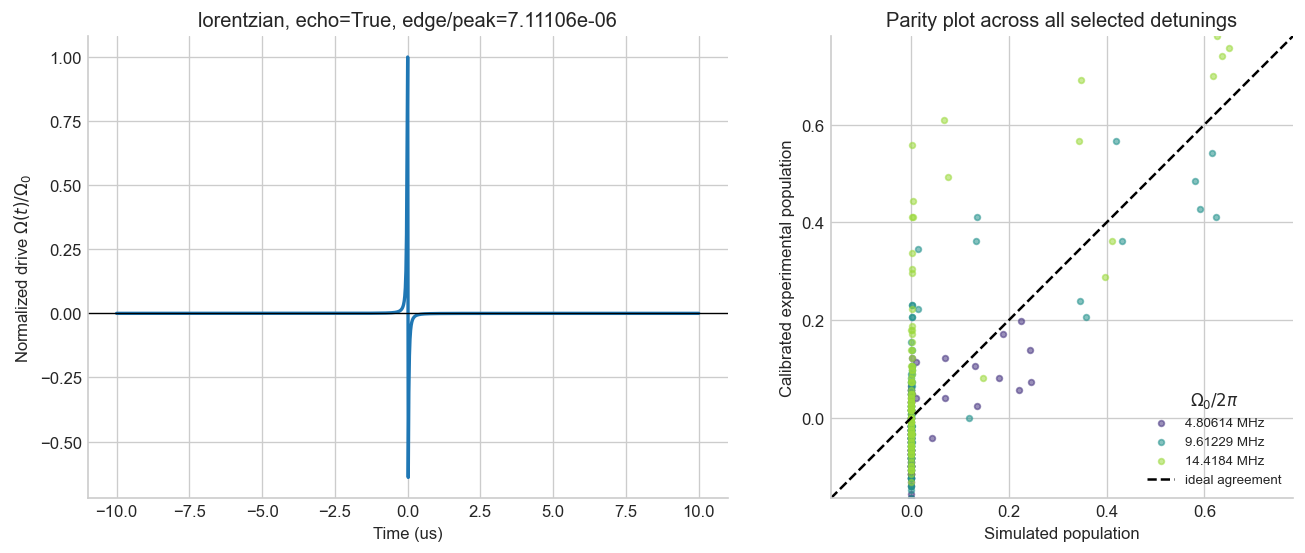

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
pulse_args = PulseArgs(
    pulse_length=dataset.pulse_length_s,
    cutoff=dataset.cutoff,
    order=float(dataset.parameters.get("order", 0.5)),
    zeroed_pulse=bool(dataset.parameters.get("zeroed_pulse", False)),
)
pulse = choose_pulse(dataset.pulse_type, dataset.echo)
time = np.linspace(-dataset.pulse_length_s / 2, dataset.pulse_length_s / 2, 1001)
envelope = np.ones_like(time) if pulse is None else pulse(time, pulse_args)
axes[0].plot(time / u.us, envelope, color="C0", lw=2)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set(
    title=f"{dataset.pulse_shape}, echo={dataset.echo}, edge/peak={dataset.cutoff:g}",
    xlabel="Time (us)",
    ylabel=r"Normalized drive $\Omega(t)/\Omega_0$",
)

for color, amp, exp_line, sim_line in zip(colors, selected_amplitudes_mhz, experimental_calibrated, simulated_at_data):
    mask = np.isfinite(exp_line) & np.isfinite(sim_line)
    axes[1].scatter(sim_line[mask], exp_line[mask], s=12, alpha=0.55, color=color, label=f"{amp:g} MHz")
limits = [
    np.nanmin([experimental_calibrated, simulated_at_data]),
    np.nanmax([experimental_calibrated, simulated_at_data]),
]
axes[1].plot(limits, limits, "k--", label="ideal agreement")
axes[1].set(
    title="Parity plot across all selected detunings",
    xlabel="Simulated population",
    ylabel="Calibrated experimental population",
    xlim=limits, ylim=limits, aspect="equal",
)
axes[1].legend(title=r"$\Omega_0/2\pi$", fontsize=8)
plt.show()


## Interpretation checklist

- Inspect the raw plots before the calibrated overlay.
- Small residuals, $R^2$ near 1, and Pearson $r$ near 1 support agreement in both scale and spectral shape.
- A large fitted frequency offset can indicate a stale qubit-frequency calibration.
- A negative or unusually small readout contrast suggests that the state convention or readout calibration needs checking.
- Structured residuals mean the data are not fully explained by this fixed-parameter model; possible causes include amplitude transfer-function error, imperfect $T_1/T_2$, pulse distortion, leakage, TLS coupling, or drift.
- For a stronger validation, repeat the comparison on data not used to choose coherence parameters or readout calibration.